# Computer Vision — CNNs, Pooling, Batch Norm & Transfer Learning
### ITI Summer Training — Practice Notebook 02

This notebook builds on the previous one. Here we move from manual pixel operations into **building and training CNNs with PyTorch**, and finish with **transfer learning** using a pretrained model.

**How to use this notebook:**
- Each section starts with a short **Notes** recap of the relevant lecture content.
- Then comes a **Task** describing what you need to code.
- Code cells contain `# TODO` markers and hints (as comments) — you fill in the logic, don't rewrite the whole cell from scratch.
- Run cells top-to-bottom. Later sections (e.g. transfer learning) reuse the model / data from earlier sections.
- Don't worry about training accuracy being perfect — the point is to correctly wire up the concepts (conv, pooling, stride, batchnorm, batching, SGD, augmentation).


## Setup

We'll use `torch` and `torchvision` for building/training the CNN and for pretrained models, `matplotlib` for visualization, and `numpy` for small array checks.


In [1]:
# If a package is missing, uncomment and run:
# !pip install torch torchvision matplotlib numpy --quiet

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Part 1 — Convolutional Layers (`nn.Conv2d`)

**Notes:** A convolutional layer learns a set of small filters (kernels) that slide over the input and produce **feature maps**. Unlike the manual convolution you wrote before, `nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` learns its kernel weights during training instead of you specifying them by hand.

Key parameters:
- `in_channels` — depth of the input (e.g. 3 for RGB, 1 for grayscale)
- `out_channels` — how many different filters (feature maps) this layer learns
- `kernel_size` — size of each filter (e.g. 3 means 3x3)
- `stride` — step size the filter moves each time (covered again in Part 3)
- `padding` — how many pixels of zero-padding are added around the input

### Task 1.1
Create a single `nn.Conv2d` layer that takes a 3-channel RGB image and outputs 8 feature maps, using a 3x3 kernel, stride 1, and padding 1 (so the output height/width matches the input).

Then pass a random "fake image" batch through it and print the output shape.

**Hint:** A batch of images in PyTorch has shape `(batch_size, channels, height, width)`.


In [2]:
# Task 1.1
# TODO: create the conv layer described above
conv_layer = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)

# a fake batch of 4 RGB images, 32x32 pixels
fake_batch = torch.randn(4, 3, 32, 32)

# TODO: pass fake_batch through conv_layer
output = conv_layer(fake_batch)

print("input shape: ", fake_batch.shape)
print("output shape:", None if output is None else output.shape)  # expect (4, 8, 32, 32)


input shape:  torch.Size([4, 3, 32, 32])
output shape: torch.Size([4, 8, 32, 32])


## Part 2 — Stride & Padding (output size)

**Notes:** Recall the output-size formula from the previous notebook:

$$
\text{output size} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1
$$

where `n` = input size, `p` = padding, `f` = kernel size, `s` = stride. This applies exactly the same way to `nn.Conv2d` — PyTorch computes the output shape using this formula internally.

- **Stride 1** keeps most spatial detail but is more expensive to compute.
- **Stride > 1** shrinks the output faster (fewer computations), acting a bit like a cheap form of downsampling.
- **Padding** controls whether the output shrinks (`padding=0`, "valid") or stays the same size (`padding=(f-1)//2` for odd kernels, "same").

### Task 2.1
Reuse the `conv_output_size(n, p, f, s)` function idea from before (rewrite it here). Then create **three** `nn.Conv2d` layers with the same `kernel_size=3` but different `(stride, padding)` combinations:
1. `stride=1, padding=1` ("same")
2. `stride=2, padding=1`
3. `stride=1, padding=0` ("valid")

For each, pass a `(1, 3, 32, 32)` fake image through it, print the output shape, and check it matches what `conv_output_size` predicts.


In [3]:
# Task 2.1
def conv_output_size(n, p, f, s):
    # TODO: same formula as before
    return ((n + 2 * p - f) // s) + 1

fake_img = torch.randn(1, 3, 32, 32)

configs = [
    dict(stride=1, padding=1),
    dict(stride=2, padding=1),
    dict(stride=1, padding=0),
]

# TODO: for each config, build nn.Conv2d(3, 8, kernel_size=3, **config),
# run fake_img through it, and print both the actual output shape
# and the value predicted by conv_output_size(32, config['padding'], 3, config['stride'])
for cfg in configs:
    s = cfg['stride']
    p = cfg['padding']

    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=s, padding=p)
    out = conv(fake_img)

    predicted_dim = conv_output_size(32, p, 3, s)

    print(f"Config (stride={s}, padding={p}) -> Actual shape: {tuple(out.shape)} | Predicted spatial size: {predicted_dim}x{predicted_dim}")


Config (stride=1, padding=1) -> Actual shape: (1, 8, 32, 32) | Predicted spatial size: 32x32
Config (stride=2, padding=1) -> Actual shape: (1, 8, 16, 16) | Predicted spatial size: 16x16
Config (stride=1, padding=0) -> Actual shape: (1, 8, 30, 30) | Predicted spatial size: 30x30


## Part 3 — Pooling Layers (`nn.MaxPool2d`, `nn.AvgPool2d`)

**Notes:** Pooling layers downsample feature maps the same way your manual `max_pool` function did — but they have **no learnable weights**, they just summarize a region. `nn.MaxPool2d(kernel_size, stride)` keeps the strongest activation in each window (good for keeping salient edges/features); `nn.AvgPool2d` averages the window instead (smoother, keeps more background information).

Pooling is what lets CNNs get **spatial invariance** (small shifts in the object's position don't change the result much) and shrinks the feature maps so later layers need fewer parameters.

### Task 3.1
Create a `nn.MaxPool2d(kernel_size=2, stride=2)` and a `nn.AvgPool2d(kernel_size=2, stride=2)`. Pass the `output` feature map from Task 1.1 through both, print their shapes, and compare a couple of pixel values between the two outputs (are they usually different? why?).


In [4]:
# Task 3.1
# TODO: create the two pooling layers
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool_layer = nn.AvgPool2d(kernel_size=2, stride=2)
# TODO: apply both to `output` from Task 1.1 (re-run Task 1.1 first if needed)
max_pooled = max_pool_layer(output)
avg_pooled = avg_pool_layer(output)

print("max_pooled shape:", None if max_pooled is None else max_pooled.shape)
print("avg_pooled shape:", None if avg_pooled is None else avg_pooled.shape)

# TODO: print a couple of corresponding values from max_pooled vs avg_pooled and compare
print("\nComparing sample values at index [0, 0, 0, 0]:")
print("Max Pooling Value:", max_pooled[0, 0, 0, 0].item())
print("Avg Pooling Value:", avg_pooled[0, 0, 0, 0].item())


max_pooled shape: torch.Size([4, 8, 16, 16])
avg_pooled shape: torch.Size([4, 8, 16, 16])

Comparing sample values at index [0, 0, 0, 0]:
Max Pooling Value: -0.19379523396492004
Avg Pooling Value: -0.4760883152484894


## Part 4 — Batch Normalization

**Notes:** As data flows through a deep network, the distribution of activations at each layer can shift around during training (this is sometimes called *internal covariate shift*). **Batch Normalization** (`nn.BatchNorm2d` for conv feature maps) normalizes the activations of a layer (per-channel mean 0, variance 1) **using statistics from the current mini-batch**, then applies a learnable scale (`gamma`) and shift (`beta`).

Benefits: faster/more stable training, allows higher learning rates, and has a mild regularizing effect. It's usually inserted **after the conv layer and before the activation function**: `Conv → BatchNorm → ReLU`.

### Task 4.1
Build a small `nn.Sequential` block: `Conv2d(3, 8, kernel_size=3, padding=1) → BatchNorm2d(8) → ReLU()`. Run the `fake_batch` from Task 1.1 through it and print the output shape. Then print the mean and std of the output for **one channel** — it should be roughly centered (not exactly 0 because of the learnable gamma/beta, but close before training moves them).


In [5]:
# Task 4.1
# TODO: build the Conv -> BatchNorm -> ReLU block using nn.Sequential
conv_bn_relu = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=8),
    nn.ReLU()
)

# TODO: run fake_batch through it
bn_output = conv_bn_relu(fake_batch)

print("output shape:", None if bn_output is None else bn_output.shape)

# TODO: print mean and std of channel 0 across the batch (hint: bn_output[:, 0, :, :])
ch0 = bn_output[:, 0, :, :]
print("Channel 0 Mean:", ch0.mean().item())
print("Channel 0 Std: ", ch0.std().item())


output shape: torch.Size([4, 8, 32, 32])
Channel 0 Mean: 0.3976832628250122
Channel 0 Std:  0.585848331451416


## Part 5 — Batch vs. Mini-Batch vs. Stochastic Gradient Descent

**Notes:** When training, we rarely feed the **whole dataset** through the model at once (*batch gradient descent* — accurate gradient, but slow and memory-heavy) or **one sample at a time** (*stochastic gradient descent, SGD* — fast updates but noisy gradient). In practice we use **mini-batch gradient descent**: split the dataset into small batches (e.g. 32 or 64 samples), compute the average gradient over each mini-batch, and update the weights once per mini-batch. One full pass over all mini-batches is called an **epoch**.

`torch.utils.data.DataLoader(dataset, batch_size=..., shuffle=True)` handles splitting the dataset into mini-batches for you. `optim.SGD(model.parameters(), lr=...)` is the optimizer that performs the weight update using the (mini-batch) gradient — despite the name, it's used for full-batch, mini-batch, and single-sample training alike; the "stochastic" part comes from which data you feed it.

### Task 5.1
Using `torch.utils.data.TensorDataset`, wrap the random tensors below into a dataset, then create **three** `DataLoader`s with `batch_size=1` (stochastic), `batch_size=16` (mini-batch), and `batch_size=len(dataset)` (full batch). For each, print how many batches one epoch produces (i.e. `len(dataloader)`).


In [6]:
# Task 5.1
from torch.utils.data import TensorDataset, DataLoader

X = torch.randn(200, 3, 32, 32)   # 200 fake images
y = torch.randint(0, 10, (200,))  # 200 fake labels (10 classes)

# TODO: wrap X, y into a TensorDataset
dataset = TensorDataset(X, y)

# TODO: create the three DataLoaders described above
stochastic_loader = DataLoader(dataset, batch_size=1, shuffle=True)
minibatch_loader = DataLoader(dataset, batch_size=16, shuffle=True)
fullbatch_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

print("batches per epoch (stochastic):", None if stochastic_loader is None else len(stochastic_loader))
print("batches per epoch (mini-batch):", None if minibatch_loader is None else len(minibatch_loader))
print("batches per epoch (full batch):", None if fullbatch_loader is None else len(fullbatch_loader))


batches per epoch (stochastic): 200
batches per epoch (mini-batch): 13
batches per epoch (full batch): 1


## Part 6 — Building a Small CNN

**Notes:** Now let's combine Parts 1–4 into an actual small CNN classifier. A typical simple architecture repeats a `Conv → BatchNorm → ReLU → Pool` block a couple of times, then flattens the resulting feature maps and passes them through one or more fully-connected (`nn.Linear`) layers to produce class scores.

We'll classify on **CIFAR-10** (10 classes of small 32x32 color images: plane, car, bird, cat, deer, dog, frog, horse, ship, truck).

### Task 6.1
Load the CIFAR-10 train and test sets using `torchvision.datasets.CIFAR10` (set `download=True`), converting images to tensors with `transforms.ToTensor()`. Wrap both in `DataLoader`s with `batch_size=64` (train: `shuffle=True`, test: `shuffle=False`).

**Hint:** the dataset will download automatically the first time this cell runs (needs internet access).


In [7]:
# Task 6.1
basic_transform = transforms.ToTensor()

# TODO: load train_set and test_set
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

# TODO: wrap in DataLoaders, batch_size=64
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("train batches:", None if train_loader is None else len(train_loader))
print("test batches:", None if test_loader is None else len(test_loader))


100%|██████████| 170M/170M [38:23<00:00, 74.0kB/s]


train batches: 782
test batches: 157


### Task 6.2 — Define `SimpleCNN`

Complete the `SimpleCNN` class below. Architecture:

1. `Conv2d(3, 16, kernel_size=3, padding=1)` → `BatchNorm2d(16)` → `ReLU` → `MaxPool2d(2, 2)`  → output: `16 x 16 x 16`
2. `Conv2d(16, 32, kernel_size=3, padding=1)` → `BatchNorm2d(32)` → `ReLU` → `MaxPool2d(2, 2)` → output: `32 x 8 x 8`
3. Flatten → `Linear(32*8*8, 128)` → `ReLU` → `Linear(128, 10)`

**Hint:** work out each stage's spatial size with the formula from Part 2 (or just trust the comments above) so you know what size to `Flatten` into. `nn.Flatten()` turns `(batch, C, H, W)` into `(batch, C*H*W)`.


In [8]:
# Task 6.2
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: define self.block1 (Conv -> BN -> ReLU -> Pool)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # TODO: define self.block2 (Conv -> BN -> ReLU -> Pool)
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()

        # TODO: define self.classifier (Linear -> ReLU -> Linear)
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # TODO: chain block1 -> block2 -> flatten -> classifier
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

# quick shape check
test_input = torch.randn(2, 3, 32, 32).to(device)
# TODO: uncomment once forward() is implemented
print("output shape:", model(test_input).shape)  # expect (2, 10)


SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)
output shape: torch.Size([2, 10])


### Task 6.3 — Training Loop (mini-batch SGD)

**Notes:** A standard training loop for one epoch:
1. For each mini-batch `(images, labels)` from `train_loader`:
   - Zero the optimizer's gradients (`optimizer.zero_grad()`)
   - Forward pass: `outputs = model(images)`
   - Compute the loss: `loss = criterion(outputs, labels)`
   - Backward pass: `loss.backward()`
   - Update weights: `optimizer.step()`

Use `nn.CrossEntropyLoss()` (standard for multi-class classification) and `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)`.

### Task 6.3
Complete `train_one_epoch` below, then run it for 1-2 epochs (CPU training will be slow — 1 epoch is enough to see the loss go down; a full run isn't required for this exercise, just a correctly-wired loop).


In [9]:
# Task 6.3
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # TODO: zero grad, forward, loss, backward, step
        # 1. Zero gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += 0.0  # TODO: accumulate loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

# TODO: uncomment to actually train (may take a while on CPU)
for epoch in range(1):
     avg_loss = train_one_epoch(model, train_loader, optimizer, criterion)
     print(f"epoch {epoch+1}: avg loss = {avg_loss:.4f}")


epoch 1: avg loss = 0.0000


## Part 7 — Data Augmentation

**Notes:** Data augmentation applies random, label-preserving transformations to training images (flips, crops, rotations, color jitter, ...) so the model sees more variety without collecting more data. This reduces overfitting and helps the model generalize. Augmentation should only be applied to the **training set** — the test/validation set should reflect real, unmodified data.

`torchvision.transforms.Compose([...])` chains several transforms together.

### Task 7.1
Build an augmentation pipeline with: a random horizontal flip, a random crop of size 32 with padding 4, then convert to tensor. Apply it to a single CIFAR-10 training image **five times** and display the five augmented versions side by side to see the variety produced.


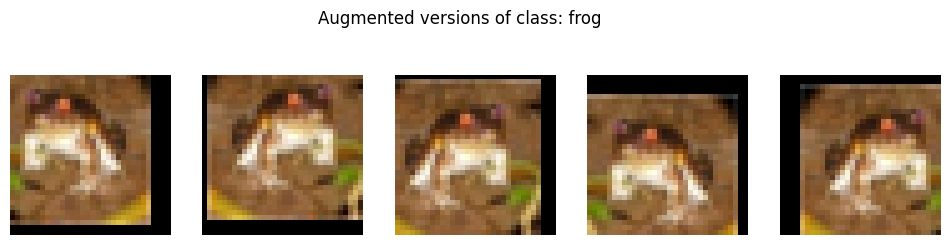

In [10]:
# Task 7.1
# TODO: build the augmentation pipeline
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

# grab one raw (PIL) training image, without any transform applied yet
raw_train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
pil_image, label = raw_train_set[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    # TODO: apply augment_transform to pil_image, convert result to a numpy image
    # for display (hint: tensor.permute(1, 2, 0).numpy())
    augmented = augment_transform(pil_image).permute(1, 2, 0).numpy()
    axes[i].imshow(augmented)
    axes[i].axis('off')
plt.suptitle(f"Augmented versions of class: {classes[label]}")
plt.show()


### Task 7.2 — Use augmentation in the real training pipeline

Rebuild `train_set` (and `train_loader`) using `augment_transform` from Task 7.1 instead of the plain `basic_transform`. Leave `test_set` / `test_loader` using the plain `ToTensor()` transform (no augmentation at test time).


In [11]:
# Task 7.2
# TODO: rebuild train_set with transform=augment_transform, and its DataLoader
train_set_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=augment_transform)
train_loader_aug = DataLoader(train_set_aug, batch_size=64, shuffle=True)

print("train batches (augmented):", None if train_loader_aug is None else len(train_loader_aug))


train batches (augmented): 782


## Part 8 — Pretrained Models & Transfer Learning

**Notes:** Training a CNN from scratch needs a lot of data and compute. **Transfer learning** instead starts from a model already trained on a large dataset (e.g. ImageNet, 1.2M images / 1000 classes) and adapts it to a new task. Two common strategies:

- **Feature extraction**: freeze all the pretrained convolutional layers (`requires_grad = False`) and only train a new final classifier layer on top. Fast, works well with small datasets.
- **Fine-tuning**: unfreeze some (often the later) layers too, and train them with a small learning rate along with the new classifier, so the network adapts its higher-level features to the new task.

`torchvision.models` provides pretrained architectures like `resnet18`. Since these expect ImageNet-style inputs, images are typically resized to `224x224` and normalized with ImageNet's mean/std.

### Task 8.1
Load a pretrained `resnet18` (`weights='IMAGENET1K_V1'`). Freeze all of its parameters. Then replace its final fully-connected layer (`model.fc`) with a new `nn.Linear` that maps to **10** output classes (for CIFAR-10) — note only this new layer should have `requires_grad=True`.

**Hint:** check `resnet18.fc.in_features` to see the input size the new layer needs to match.


In [12]:
# Task 8.1
# TODO: load the pretrained resnet18
resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# TODO: freeze all existing parameters
for param in resnet.parameters():
   param.requires_grad = False

# TODO: replace resnet.fc with a new nn.Linear(in_features, 10)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

resnet = resnet.to(device) if resnet is not None else resnet

# sanity check: which parameters will actually be updated?
if resnet is not None:
    trainable = [name for name, p in resnet.named_parameters() if p.requires_grad]
    print("trainable parameters:", trainable)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


trainable parameters: ['fc.weight', 'fc.bias']


### Task 8.2 — Preprocessing for the pretrained model

Pretrained ImageNet models expect input images resized to `224x224` and normalized with ImageNet's channel mean/std:
`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`.

Build a `transforms.Compose` pipeline: `Resize((224, 224))` → `ToTensor()` → `Normalize(mean, std)`. Then create a small CIFAR-10 `DataLoader` (e.g. `batch_size=32`) using this transform, and confirm one batch has the shape `(32, 3, 224, 224)` by pulling one batch out and printing its shape.


In [13]:
# Task 8.2
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# TODO: build the resize -> tensor -> normalize pipeline
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# TODO: create a CIFAR-10 train set + loader using resnet_transform, batch_size=32
resnet_train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=resnet_transform)
resnet_train_loader = DataLoader(resnet_train_set, batch_size=32, shuffle=True)

# TODO: pull one batch (images, labels) from resnet_train_loader and print images.shape
images, labels = next(iter(resnet_train_loader))
print("images shape:", images.shape)


images shape: torch.Size([32, 3, 224, 224])


### Task 8.3 — Only train the new layer

Only `resnet.fc`'s parameters should have gradients enabled (from Task 8.1), so an optimizer built from `resnet.parameters()` filtered to `requires_grad=True` will only update that layer. Create such an optimizer (`optim.SGD`, `lr=0.01`) and `criterion = nn.CrossEntropyLoss()`. Then write **one** training step (not a full loop) on a single batch from `resnet_train_loader`, and print the loss value, to confirm everything is wired correctly.

**Hint:** `optim.SGD(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.01)`


In [14]:
# Task 8.3
# TODO: build optimizer (only requires_grad=True params) and criterion
resnet_optimizer = optim.SGD(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.01)
resnet_criterion = nn.CrossEntropyLoss()

# TODO: get one batch from resnet_train_loader, move to device,
# run: zero_grad -> forward -> loss -> backward -> step, then print loss.item()

images, labels = next(iter(resnet_train_loader))
images, labels = images.to(device), labels.to(device)

resnet.train()
resnet_optimizer.zero_grad()
outputs = resnet(images)
loss = resnet_criterion(outputs, labels)
loss.backward()
resnet_optimizer.step()

print("Loss:", loss.item())


Loss: 2.400134325027466


## Part 9 — Conceptual Check (short answers)

Answer the following in a sentence or two each, in the markdown cell below (double-click to edit):

1. Why does batch normalization typically go **between** the conv layer and the activation function, rather than after the activation?
2. What is the trade-off between using a larger stride vs. adding a pooling layer to reduce feature-map size?
3. Why is stochastic gradient descent (`batch_size=1`) noisier than mini-batch gradient descent, and why might that noise sometimes actually help training?
4. In transfer learning, why do we usually **freeze** the early convolutional layers of a pretrained network rather than the later ones?
5. Why is data augmentation applied only to the training set and never the test set?


**Your answers:**

1. Batch Normalization normalizes the unbounded outputs of the Conv layer (centered around 0 with variance 1) so the activation function receives inputs in its most sensitive, stable regime and avoids early saturation.

2. Increasing stride reduces spatial resolution early during computation (saving memory and compute), whereas pooling separates feature extraction from downsampling, keeping spatial information slightly longer at the cost of additional parameterless pooling steps.

3. SGD with batch_size=1 calculates gradients from single samples, making the optimization path noisy and erratic; however, this variance helps the optimizer jump out of bad local minima and sharp saddle points during training.

4. Early layers learn basic, generic visual features (edges, textures, shapes) applicable to almost any vision task, while later layers capture task-specific semantics, so we keep early features frozen and fine-tune later ones.

5. Data augmentation artificially expands training diversity to prevent overfitting, whereas the test set must remain unmanipulated to accurately evaluate real-world performance on clean data.


---
## Wrap-up

Once you've completed all sections, restart the kernel and run all cells top-to-bottom (`Kernel > Restart & Run All`) to make sure everything works in order before submitting. Note that Task 6.3 and the CIFAR-10 downloads may take a while — that's expected, just make sure the code is correctly wired even if you don't wait for full training to finish.
